In [25]:
import warnings
warnings.filterwarnings('ignore')

# Specifically for Keras/TensorFlow warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [12]:
# Installing yfinance API
!pip install yfinance joblib

1.Importing the Dependencies

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import joblib # For saving .sav files
import datetime

# Setting plot style
plt.style.use('fivethirtyeight')

2.Data Cleaning & Extraction (API Setup)

In [14]:
# Extracting live data from Yahoo Finance API
ticker = "AAPL" # You can change this to any stock symbol
start_date = "2015-01-01"
end_date = datetime.datetime.now().strftime('%Y-%m-%d')

df = yf.download(ticker, start=start_date, end=end_date)

# Checking for null values and dropping them
print(f"Missing values:\n{df.isnull().sum()}")
df.dropna(inplace=True)

# Resetting index to have 'Date' as a column
df.reset_index(inplace=True)

/tmp/ipykernel_7428/2239853225.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Missing values:
Price   Ticker
Close   AAPL      1
High    AAPL      1
Low     AAPL      1
Open    AAPL      1
Volume  AAPL      0
dtype: int64


3.Data Visualization

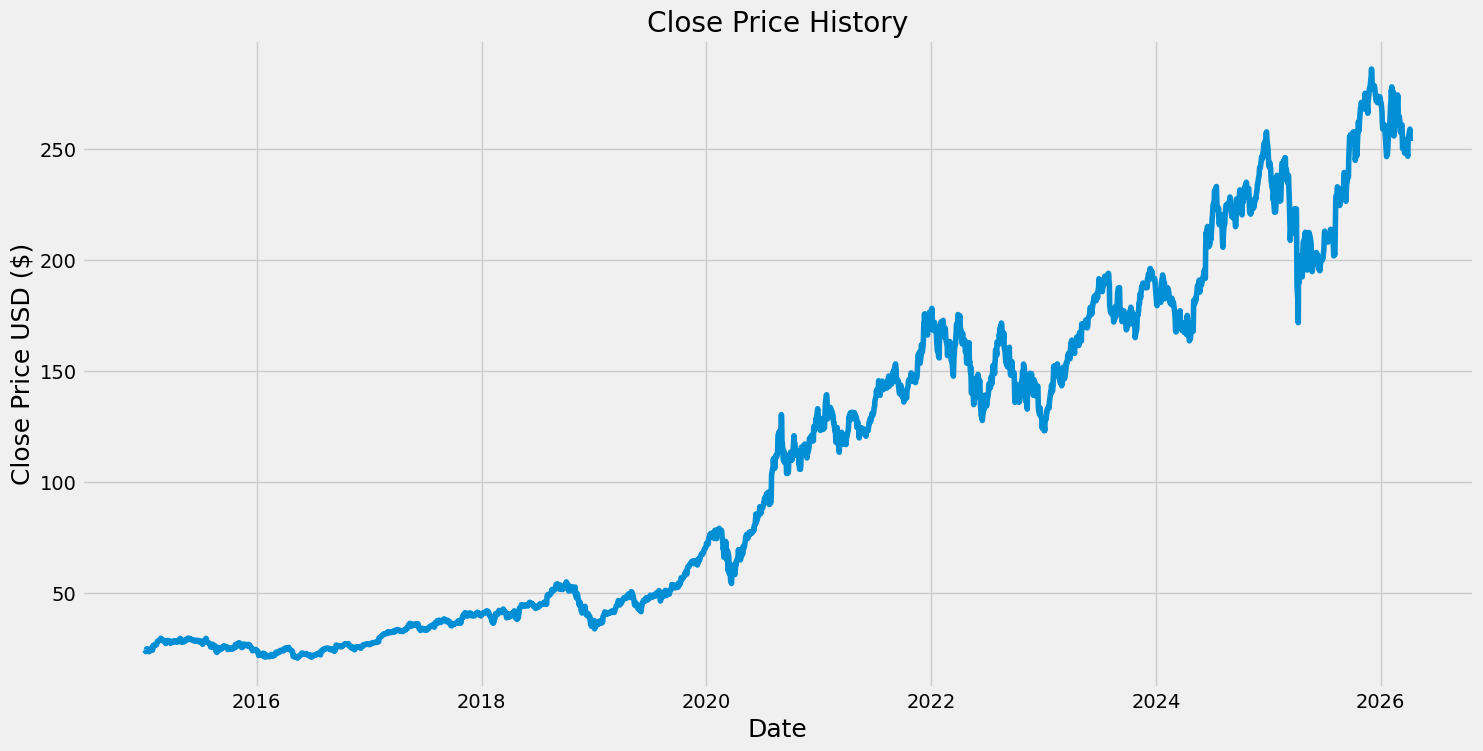

In [15]:
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Date'], df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

4.Exploratory Data Analysis (EDA)

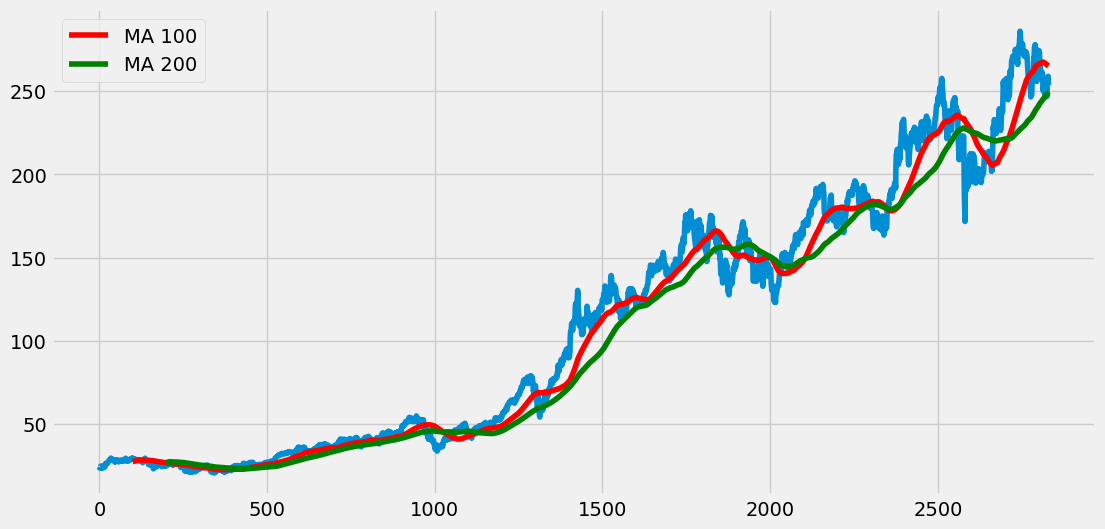

In [16]:
# 100-day and 200-day Moving Averages
ma100 = df.Close.rolling(100).mean()
ma200 = df.Close.rolling(200).mean()

plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r', label='MA 100')
plt.plot(ma200, 'g', label='MA 200')
plt.legend()
plt.show()

5.Data Modeling (Preprocessing)

In [17]:
# Scaling the data (Normalization)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

# Creating a data structure with 60 timesteps
prediction_days = 60
x_data, y_data = [], []

for x in range(prediction_days, len(scaled_data)):
    x_data.append(scaled_data[x-prediction_days:x, 0])
    y_data.append(scaled_data[x, 0])

x_data, y_data = np.array(x_data), np.array(y_data)
x_data = np.reshape(x_data, (x_data.shape[0], x_data.shape[1], 1))

6.Splitting into Features, Target, Train and Test

In [18]:
# Since it's time series, we split sequentially, not randomly
train_size = int(len(x_data) * 0.8)
x_train, x_test = x_data[:train_size], x_data[train_size:]
y_train, y_test = y_data[:train_size], y_data[train_size:]

7.Model Training

In [19]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Prediction of the next Close value

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=25, batch_size=32)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0073
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0011
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0010
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 9.6374e-04
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 9.0359e-04
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.4684e-04
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.2820e-04
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9053e-04
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.1150e-04
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.6044e-04
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7190e-04
Epoch 13/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4181e-04
Epoch 14/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.6679e-04
Epoch 15/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/s

8.Model Evaluation

In [20]:
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions) # Scaling back to original price
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1,1))

rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
print(f"Root Mean Squared Error: {rmse}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Root Mean Squared Error: 10.734556855953546


9.Communication and Visualization (Results)

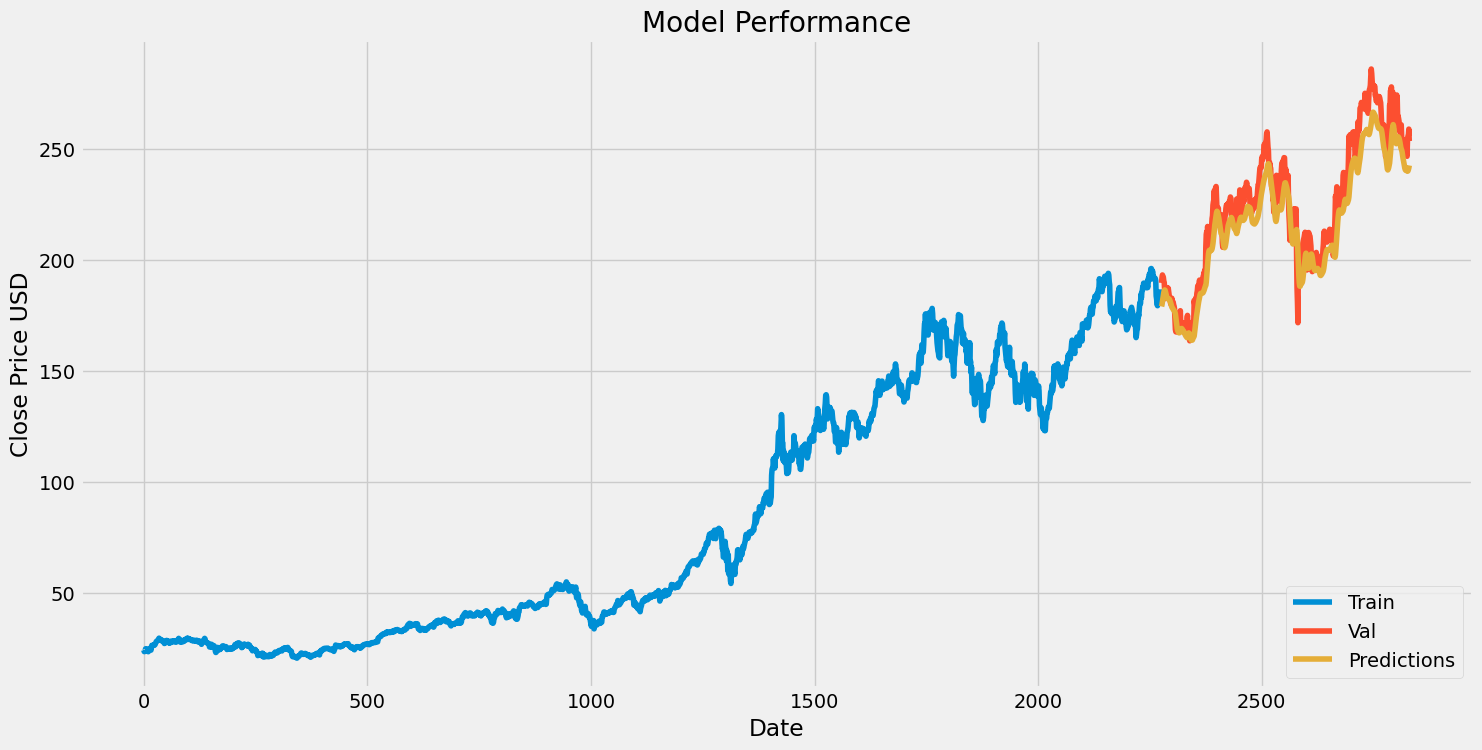

In [22]:
# 1. Create a clean copy of the validation set
valid = df[train_size + prediction_days:].copy()

# 2. Add the predictions to this specific 'valid' dataframe
valid['Predictions'] = predictions

# 3. Now Plotting
plt.figure(figsize=(16,8))
plt.title('Model Performance')
plt.xlabel('Date')
plt.ylabel('Close Price USD')

# Plotting the training data
plt.plot(train['Close'])

# Plotting the actual vs predicted values from the 'valid' dataframe
plt.plot(valid[['Close', 'Predictions']])

plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

10.Model Saving (.sav format)

In [23]:
# Keras models are typically .h5, but we wrap it for .sav if required
joblib.dump(model, 'stock_model.sav')
joblib.dump(scaler, 'scaler.sav')

['scaler.sav']

11.Data Automated Pipeline & Saving

In [24]:
def automated_pipeline(ticker_symbol):
    raw_data = yf.download(ticker_symbol, period='1y')
    # Preprocessing logic here...
    return raw_data

# Saving pipeline configuration
pipeline_config = {'ticker': ticker, 'scaler': 'scaler.sav', 'model': 'stock_model.sav'}
joblib.dump(pipeline_config, 'pipeline_config.sav', compress=3)
print("Pipeline saved successfully!")

Pipeline saved successfully!
